In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Automatically detect the dataset location to prevent path errors
found_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'styles.csv' in files:
        found_path = root
        break

if found_path:
    DATASET_PATH = found_path
    print(f"Dataset located successfully at: {DATASET_PATH}")
else:
    # Fallback to default Kaggle extraction format if not automatically found
    DATASET_PATH = "/kaggle/input/fashion-product-images-small/myntradataset/"
    print(f"Dataset path not auto-detected. Falling back to default: {DATASET_PATH}")

CSV_PATH = os.path.join(DATASET_PATH, "styles.csv")
IMAGE_DIR = os.path.join(DATASET_PATH, "images")

print(f"Verification -> Catalog CSV exists: {os.path.exists(CSV_PATH)}")
print(f"Verification -> Images directory exists: {os.path.exists(IMAGE_DIR)}")

Dataset located successfully at: /kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset
Verification -> Catalog CSV exists: True
Verification -> Images directory exists: True


In [2]:
# Read the catalog dataset, ignoring structurally flawed rows gracefully
df = pd.read_csv(CSV_PATH, on_bad_lines='skip')

# Drop items missing crucial categorical tags or IDs, then clean data types
df = df.dropna(subset=['id', 'masterCategory', 'subCategory', 'articleType'])
df['id'] = df['id'].astype(int)

print(f"Total valid products processed into catalog: {df.shape[0]}")
print("Available Metadata Fields:", df.columns.tolist())
df.head(3)

Total valid products processed into catalog: 44424
Available Metadata Fields: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch


In [3]:
# Broad cross-category lookup dictionary mapping primary categories to companions
COMPLEMENTARY_RULES = {
    'Footwear': ['Apparel', 'Accessories'],
    'Apparel': ['Footwear', 'Accessories'],
    'Accessories': ['Apparel', 'Footwear'],
    'Personal Care': ['Accessories', 'Apparel']
}

# Fine-grained contextual sub-mapping rules for specific high-density article types
ARTICLE_RULES = {
    'Sports Shoes': ['Track Pants', 'Tshirts', 'Socks'],
    'Formal Shoes': ['Shirts', 'Trousers', 'Belts'],
    'Sarees': ['Heels', 'Clutches'],
    'Tshirts': ['Jeans', 'Casual Shoes', 'Sunglasses'],
    'Shirts': ['Trousers', 'Formal Shoes', 'Watches']
}

In [4]:
class SmartComplementaryRecommender:
    def __init__(self, metadata_df, image_dir):
        self.df = metadata_df
        self.image_dir = image_dir

    def get_complements(self, product_id, top_n=3):
        # 1. Look up target reference details
        target_row = self.df[self.df['id'] == product_id]
        if target_row.empty:
            return None, []
        
        target = target_row.iloc[0]
        
        # 2. Match baseline demographic constraints (Gender & Usage lifestyle profile)
        candidates = self.df[
            (self.df['id'] != product_id) & 
            (self.df['gender'] == target['gender']) & 
            (self.df['usage'] == target['usage'])
        ]
        
        # 3. Apply rule-based scoring priority check
        matched_articles = ARTICLE_RULES.get(target['articleType'], [])
        allowed_masters = COMPLEMENTARY_RULES.get(target['masterCategory'], [])
        
        # Separate candidate pools based on affinity strength mapping
        high_affinity = candidates[candidates['articleType'].isin(matched_articles)]
        mid_affinity = candidates[candidates['masterCategory'].isin(allowed_masters)]
        
        # Combine matching groups sequentially while ensuring unique sub-categories for variety
        recommendations = pd.concat([high_affinity, mid_affinity, candidates]).drop_duplicates(subset=['subCategory'])
        
        # Fallback layer to fill slots if unique sub-categories run low
        if len(recommendations) < top_n:
            recommendations = pd.concat([recommendations, candidates]).drop_duplicates(subset=['id'])
            
        return target, recommendations.head(top_n)

In [5]:
def plot_recommendations(target, recommendations, image_dir):
    num_recs = len(recommendations)
    fig, axes = plt.subplots(1, num_recs + 1, figsize=(4 * (num_recs + 1), 5))
    
    # Render Target Reference Input Item
    target_img_path = os.path.join(image_dir, f"{target['id']}.jpg")
    if os.path.exists(target_img_path):
        img = Image.open(target_img_path)
        axes[0].imshow(img)
    axes[0].set_title(f"INPUT:\n{target['productDisplayName']}\n({target['articleType']})", color='blue', fontsize=10)
    axes[0].axis('off')
    
    # Loop over and render product bundle companions
    for idx, (_, rec_item) in enumerate(recommendations.iterrows()):
        rec_img_path = os.path.join(image_dir, f"{rec_item['id']}.jpg")
        ax = axes[idx + 1]
        
        if os.path.exists(rec_img_path):
            img = Image.open(rec_img_path)
            ax.imshow(img)
            
        ax.set_title(f"RECOMMENDED:\n{rec_item['productDisplayName']}\n({rec_item['articleType']})", color='green', fontsize=10)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

Successfully calculated smart cross-sell bundle rules for item ID: 53759


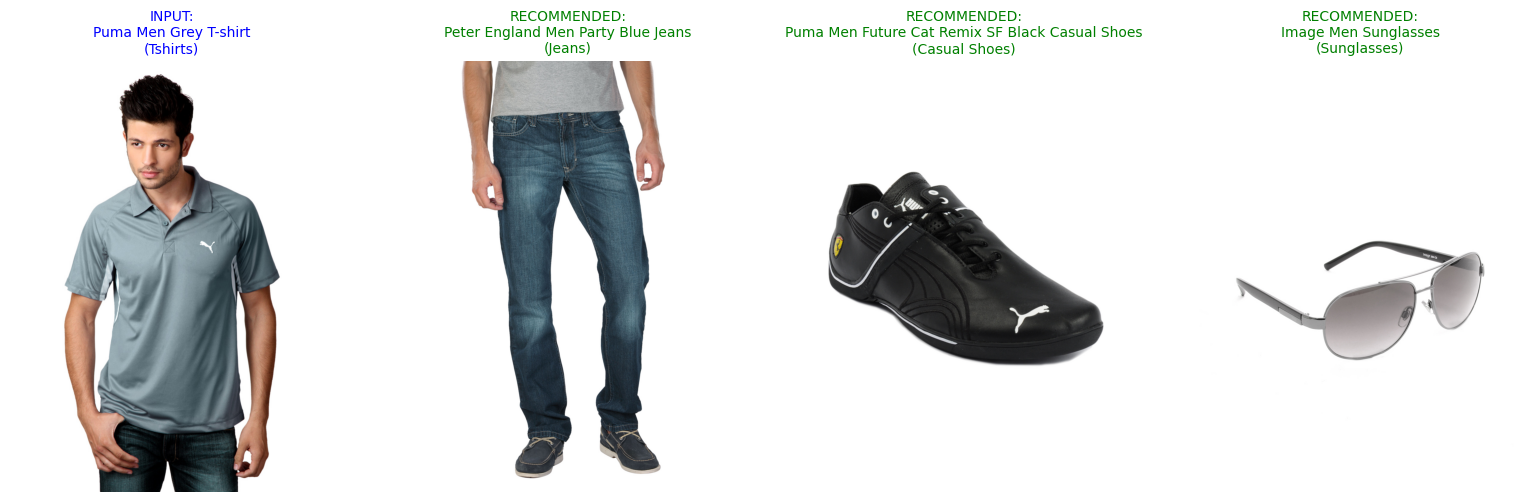

In [6]:
# Instantiate the system engine
recommender = SmartComplementaryRecommender(df, IMAGE_DIR)

# Select a test catalog product sample row (e.g., product at index position 4)
sample_id = df['id'].iloc[4]

target_item, cross_sell_bundle = recommender.get_complements(product_id=sample_id, top_n=3)

if target_item is not None:
    print(f"Successfully calculated smart cross-sell bundle rules for item ID: {sample_id}")
    plot_recommendations(target_item, cross_sell_bundle, IMAGE_DIR)
else:
    print("Requested sample product token missing inside active catalog database frames.")

In [7]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.5 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-i5j2o8ev
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-i5j2o8ev
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 86.8 MB/s eta 0:00:00:00:01:01
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=96c1a021c67826c7ec20421851e3bf99f497e4a9c16415a16b04dcc3225d0198
  Stored in directory: /tmp/pip-ephem-wheel-cache-p1f7xc8f/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency

In [8]:
import torch
import clip

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print(f"CLIP loaded on: {device}")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 188MiB/s]


CLIP loaded on: cuda


In [9]:
# Work with a manageable subset for speed — increase later if needed
df_subset = df.sample(800, random_state=42).reset_index(drop=True)

def get_image_embedding(product_id, image_dir):
    img_path = os.path.join(image_dir, f"{product_id}.jpg")
    if not os.path.exists(img_path):
        return None
    image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        embedding = model.encode_image(image)
    return embedding.cpu().numpy().flatten()

In [10]:
from tqdm import tqdm

embeddings_list = []
valid_indices = []

for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
    emb = get_image_embedding(row['id'], IMAGE_DIR)
    if emb is not None:
        embeddings_list.append(emb)
        valid_indices.append(idx)

embeddings = np.array(embeddings_list)
catalog = df_subset.loc[valid_indices].reset_index(drop=True)

print(f"Embeddings generated for {len(catalog)} products. Shape: {embeddings.shape}")

100%|██████████| 800/800 [00:59<00:00, 13.41it/s]

Embeddings generated for 800 products. Shape: (800, 512)


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

class DuplicateProductDetector:
    def __init__(self, catalog_df, embeddings, threshold=0.95):
        self.df = catalog_df
        self.embeddings = embeddings
        self.threshold = threshold
        self.sim_matrix = cosine_similarity(embeddings)

    def find_duplicate_groups(self):
        visited = set()
        groups = []
        
        for i in range(len(self.df)):
            if i in visited:
                continue
            group = [i]
            visited.add(i)
            for j in range(i + 1, len(self.df)):
                if j not in visited and self.sim_matrix[i][j] > self.threshold:
                    group.append(j)
                    visited.add(j)
            groups.append(group)
        
        return groups

    def build_unique_catalog(self, groups):
        unique_rows = [self.df.iloc[group[0]] for group in groups]
        return pd.DataFrame(unique_rows).reset_index(drop=True)

In [12]:
detector = DuplicateProductDetector(catalog, embeddings, threshold=0.95)
groups = detector.find_duplicate_groups()
unique_catalog = detector.build_unique_catalog(groups)

duplicate_groups = [g for g in groups if len(g) > 1]

print(f"Original catalog size: {len(catalog)}")
print(f"Unique products after dedup: {len(unique_catalog)}")
print(f"Duplicate groups found: {len(duplicate_groups)}")

Original catalog size: 800
Unique products after dedup: 726
Duplicate groups found: 38


Showing duplicate group of 3 items:


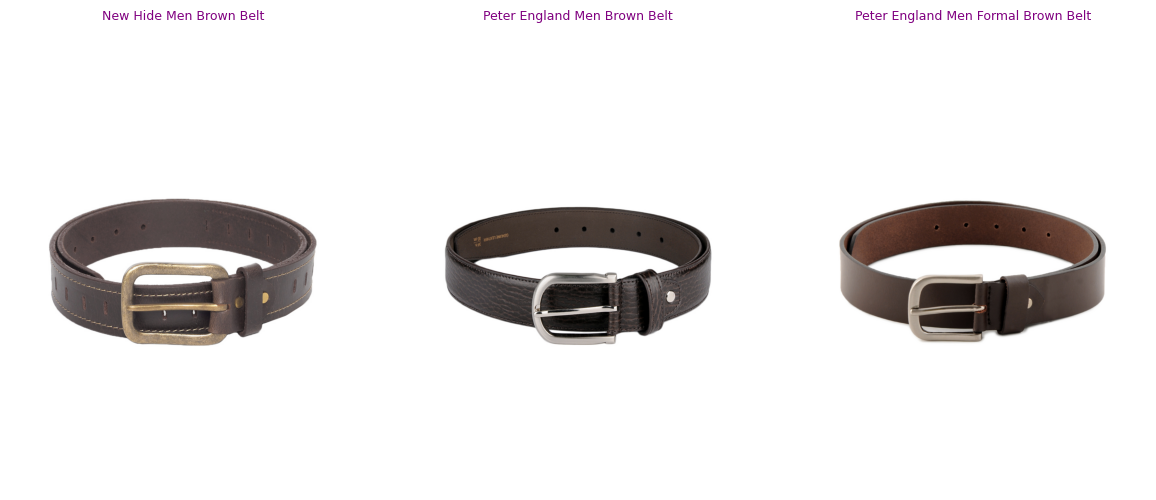

In [13]:
def plot_duplicate_group(group, catalog_df, image_dir):
    fig, axes = plt.subplots(1, len(group), figsize=(4 * len(group), 5))
    if len(group) == 1:
        axes = [axes]
    
    for idx, item_idx in enumerate(group):
        row = catalog_df.iloc[item_idx]
        img_path = os.path.join(image_dir, f"{row['id']}.jpg")
        ax = axes[idx]
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        ax.set_title(f"{row['productDisplayName']}", color='purple', fontsize=9)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Show the first duplicate group found (if any exist in your subset)
if duplicate_groups:
    print(f"Showing duplicate group of {len(duplicate_groups[0])} items:")
    plot_duplicate_group(duplicate_groups[0], catalog, IMAGE_DIR)
else:
    print("No near-duplicates found at this threshold in the current subset — try lowering threshold to ~0.90 to test.")

In [14]:
class TextToImageSearch:
    def __init__(self, catalog_df, embeddings, model, device):
        self.df = catalog_df
        self.embeddings = embeddings
        self.model = model
        self.device = device

    def search(self, query, top_k=5):
        text_token = clip.tokenize([query]).to(self.device)
        with torch.no_grad():
            text_embedding = self.model.encode_text(text_token).cpu().numpy().flatten()
        
        sims = cosine_similarity([text_embedding], self.embeddings)[0]
        top_indices = sims.argsort()[::-1][:top_k]
        
        results = self.df.iloc[top_indices].copy()
        results['similarity_score'] = sims[top_indices]
        return results

In [15]:
searcher = TextToImageSearch(catalog, embeddings, model, device)
results = searcher.search("blue casual shirt", top_k=5)

print(results[['productDisplayName', 'articleType', 'similarity_score']])

                                  productDisplayName articleType  \
727                 Wrangler Women Polka Blue Shirts      Shirts   
538                  Scullers Men Checked Blue Shirt      Shirts   
466                  Locomotive Men Check Blue Shirt      Shirts   
77                John Miller Men Striped Blue Shirt      Shirts   
652  United Colors of Benetton Men Solid Blue Shirts      Shirts   

     similarity_score  
727          0.318814  
538          0.307542  
466          0.296785  
77           0.293999  
652          0.293817  


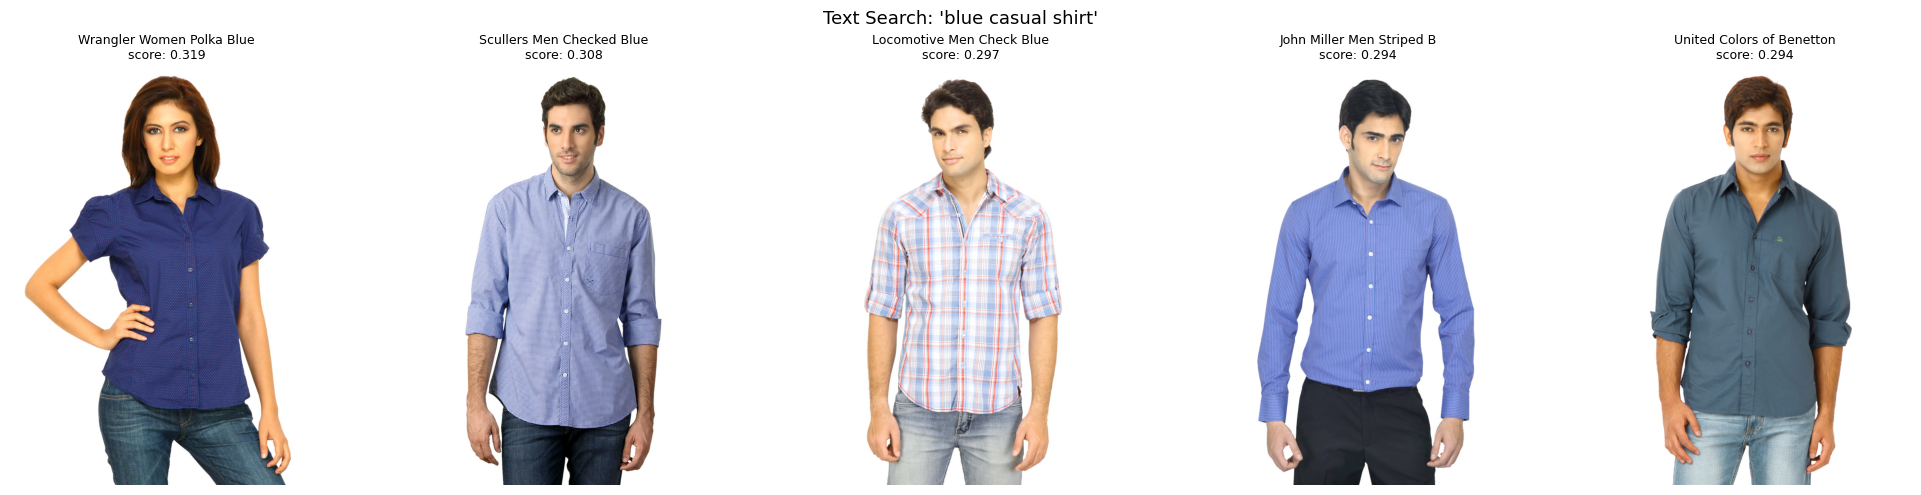

In [16]:
def plot_search_results(results, query, image_dir):
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 5))
    fig.suptitle(f"Text Search: '{query}'", fontsize=13)
    
    for idx, (_, row) in enumerate(results.iterrows()):
        img_path = os.path.join(image_dir, f"{row['id']}.jpg")
        ax = axes[idx]
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
        ax.set_title(f"{row['productDisplayName'][:25]}\nscore: {row['similarity_score']:.3f}", fontsize=9)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

plot_search_results(results, "blue casual shirt", IMAGE_DIR)

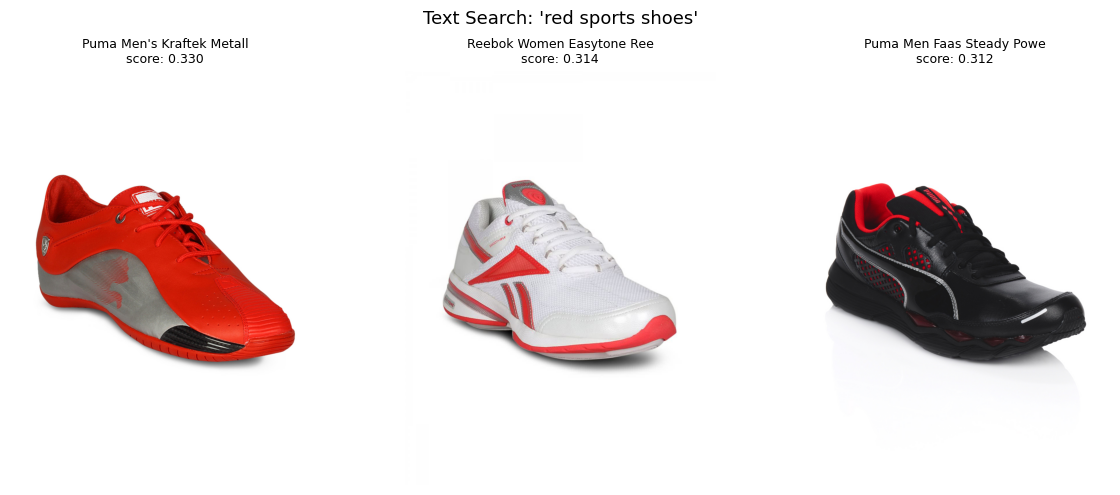

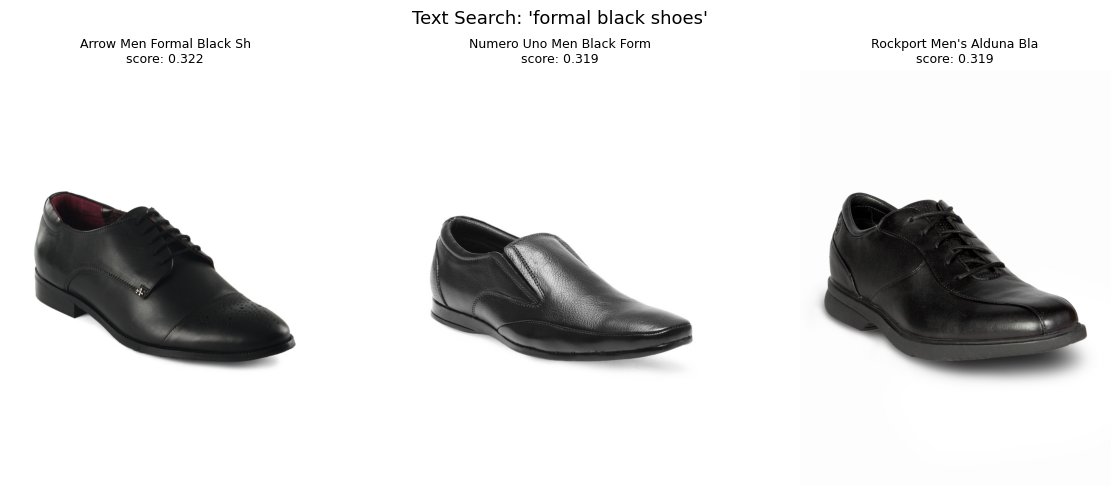

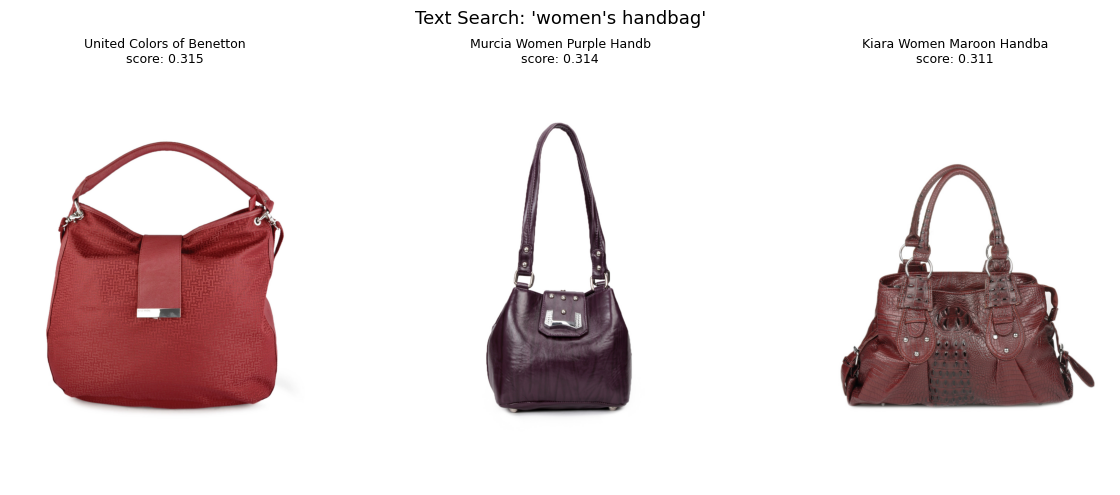

In [17]:
for query in ["red sports shoes", "formal black shoes", "women's handbag"]:
    res = searcher.search(query, top_k=3)
    plot_search_results(res, query, IMAGE_DIR)